In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from os import listdir

In [8]:
root = Path.cwd().parent.parent
figures = root / 'results' / '02_figures'
metrics = root / 'results' / 'metrics'
RUN = root / 'outputs' / listdir(root / 'outputs')[1]
runs = sorted((metrics).glob('*/training_history.csv'), key=lambda p: p.stat().st_mtime)

In [10]:
source = (Path(RUN) / 'training_history.csv') if RUN else runs[-1]
history = pd.read_csv(source, usecols=['stage', 'global_step', 'train_loss'])


In [11]:
history

,stage,global_step,train_loss
0,D_jepa_latent,152,0.401017
1,D_jepa_latent,304,0.227125
2,D_jepa_latent,456,0.190420
3,D_jepa_latent,608,0.167462
4,D_jepa_latent,760,0.159301
...,...,...,...
160,G_joint_finetune,24472,0.169072
161,G_joint_finetune,24624,0.169450
162,G_joint_finetune,24776,0.169467
163,G_joint_finetune,24928,0.168713


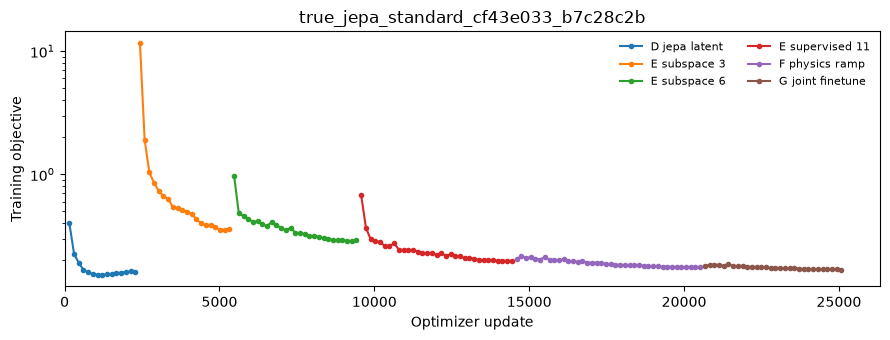

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for stage, part in history.groupby('stage', sort=False):
    ax.plot(part.global_step, part.train_loss, '-o', ms=3, label=stage.replace('_', ' '))
ax.set(xlabel='Optimizer update', ylabel='Training objective', xlim=(0, None), title=source.parent.name)
if (history.train_loss > 0).all(): ax.set_yscale('log')
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(figures / f'curriculum_{source.parent.name}.{'jpg'}', dpi=600)
plt.show()